# 12 — Enhanced Feature Engineering (v3)

Adds to v_2 model dataset:
- `age_squared` — non-linear aging curve
- `years_at_club` — consecutive seasons at from_team before transfer
- `pre_*_t2` (20) — player qualities from season T-2
- `from_q_proj_*_t2` (7) — from-team projected qualities from T-2
- `pre_minutes_t2` — minutes played in T-2
- `has_t2_history` — binary flag for T-2 data availability

NaN handling: fill T-2 with T-1 values (assume no change if no history).

In [1]:
import pandas as pd
import numpy as np
import glob, os
import matplotlib.pyplot as plt

parent = glob.glob('/Users/jorgepadilla/Documents/Documents*Jorge*MacBook*')[0]
BASE = os.path.join(parent, 'thesis_data')

V2_DATA   = f'{BASE}/processed_data/model_dataset/v_2'
OUT_DIR   = f'{BASE}/processed_data/model_dataset/v_3'
MASTER    = f'{BASE}/processed_data/master_dataset/transfers_model_2018_2025.parquet'
TEAM_STATS = f'{V2_DATA}/team_stats_z_scores_qualities.parquet'

os.makedirs(OUT_DIR, exist_ok=True)

QUALITIES = [
    'Active defence', 'Aerial threat', 'Box threat', 'Chance prevention',
    'Composure', 'Defensive heading', 'Dribbling', 'Effectiveness',
    'Finishing', 'Hold-up play', 'Intelligent defence', 'Involvement',
    'Passing quality', 'Poaching', 'Pressing', 'Progression',
    'Providing teammates', 'Run quality', 'Territorial dominance', 'Winning duels'
]

TEAM_QUALITIES = [
    'DEFENCE', 'DEFENSIVE_TRANSITION', 'ATTACKING_TRANSITION',
    'ATTACK', 'PENETRATION', 'CHANCE_CREATION', 'OUTCOME'
]

print(f'Output: {OUT_DIR}')

Output: /Users/jorgepadilla/Documents/Documents - Jorge’s MacBook Air/thesis_data/processed_data/model_dataset/v_3


In [2]:
# Load data
df = pd.read_parquet(f'{V2_DATA}/model_df.parquet')
n_original_cols = df.shape[1]

# Master: only load columns we need (539 cols is too many)
master_cols_needed = (
    ['wy_player_id', 'from_season', 'from_team_id', 'from_competition', 'from_Minutes']
    + [f'from_{q}' for q in QUALITIES]
)
master = pd.read_parquet(MASTER, columns=master_cols_needed)

team_stats = pd.read_parquet(TEAM_STATS)

print(f'model_df:   {df.shape}')
print(f'master:     {master.shape}')
print(f'team_stats: {team_stats.shape}')
print(f'\nmodel_df seasons: {sorted(df["from_season"].unique())}')
print(f'master seasons:   {sorted(master["from_season"].unique())}')

model_df:   (78231, 92)
master:     (262340, 25)
team_stats: (21800, 240)

model_df seasons: [2019, 2020, 2021, 2022, 2023]
master seasons:   [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. Age Features

In [3]:
df['age_squared'] = df['player_season_age'] ** 2
print(f'age_squared: min={df["age_squared"].min():.0f}, max={df["age_squared"].max():.0f}, mean={df["age_squared"].mean():.0f}')

age_squared: min=205, max=2913, mean=704


## 2. Years at Club

In [4]:
# For each (player, season), get their team — use first() since from_ stats are same per (player, season)
ph = master.groupby(['wy_player_id', 'from_season'])['from_team_id'].first().reset_index()
ph = ph.sort_values(['wy_player_id', 'from_season']).reset_index(drop=True)

# Identify consecutive seasons at same team
same_player    = ph['wy_player_id'] == ph['wy_player_id'].shift(1)
same_team      = ph['from_team_id'] == ph['from_team_id'].shift(1)
consecutive    = ph['from_season'] == ph['from_season'].shift(1) + 1
new_streak     = ~(same_player & same_team & consecutive)
streak_id      = new_streak.cumsum()
ph['years_at_club'] = ph.groupby(streak_id).cumcount() + 1

# Merge
df = df.merge(
    ph[['wy_player_id', 'from_season', 'years_at_club']],
    on=['wy_player_id', 'from_season'],
    how='left'
)
df['years_at_club'] = df['years_at_club'].fillna(1).astype(int)

print('years_at_club distribution:')
print(df['years_at_club'].value_counts().sort_index())

years_at_club distribution:
years_at_club
1    46269
2    19563
3     7651
4     3109
5     1193
6      446
Name: count, dtype: int64


## 3. T-2 Player Qualities

In [5]:
# Build T-2 lookup: unique (player, season) with quality scores
from_q_cols = [f'from_{q}' for q in QUALITIES]
player_t2 = master.groupby(['wy_player_id', 'from_season'])[from_q_cols + ['from_Minutes']].first().reset_index()

# merge_season: if master.from_season=2021 → that's T-2 for model_df.from_season=2022
player_t2['merge_season'] = player_t2['from_season'] + 1

# Rename: from_Active defence → pre_Active defence_t2
rename_player = {f'from_{q}': f'pre_{q}_t2' for q in QUALITIES}
rename_player['from_Minutes'] = 'pre_minutes_t2'
player_t2 = player_t2.rename(columns=rename_player)

t2_player_cols = list(rename_player.values())

# Merge on (player, from_season) = (player, merge_season)
df = df.merge(
    player_t2[['wy_player_id', 'merge_season'] + t2_player_cols],
    left_on=['wy_player_id', 'from_season'],
    right_on=['wy_player_id', 'merge_season'],
    how='left'
).drop(columns=['merge_season'])

t2_coverage = df['pre_minutes_t2'].notna().mean()
print(f'T-2 player quality coverage: {t2_coverage:.1%}')
print(f'  With T-2: {df["pre_minutes_t2"].notna().sum():,}')
print(f'  Without:  {df["pre_minutes_t2"].isna().sum():,}')

T-2 player quality coverage: 64.9%
  With T-2: 50,774
  Without:  27,457


## 4. T-2 Team Projected Qualities

In [6]:
# Step 1: Get player's team + competition in T-2
player_team_t2 = master.groupby(['wy_player_id', 'from_season'])[['from_team_id', 'from_competition']].first().reset_index()
player_team_t2['merge_season'] = player_team_t2['from_season'] + 1
player_team_t2 = player_team_t2.rename(columns={
    'from_team_id': 'team_id_t2',
    'from_season': 'season_t2',
    'from_competition': 'comp_id_t2'
})

df = df.merge(
    player_team_t2[['wy_player_id', 'merge_season', 'team_id_t2', 'season_t2', 'comp_id_t2']],
    left_on=['wy_player_id', 'from_season'],
    right_on=['wy_player_id', 'merge_season'],
    how='left'
).drop(columns=['merge_season'])

# Step 2: Get q_proj from team_stats
q_proj_cols = [f'q_proj_{q}' for q in TEAM_QUALITIES]
team_lookup = team_stats[['team_id', 'competition_id', 'season'] + q_proj_cols].copy()

# Rename: q_proj_DEFENCE → from_q_proj_DEFENCE_t2
rename_team = {c: f'from_{c}_t2' for c in q_proj_cols}
team_lookup = team_lookup.rename(columns=rename_team)
t2_team_cols = list(rename_team.values())

# Cast dtypes for merge (team_stats uses int64, model_df int32)
for c in ['team_id_t2', 'comp_id_t2', 'season_t2']:
    if c in df.columns:
        df[c] = df[c].astype('Int64')  # nullable int for NaN rows

df = df.merge(
    team_lookup,
    left_on=['team_id_t2', 'comp_id_t2', 'season_t2'],
    right_on=['team_id', 'competition_id', 'season'],
    how='left'
).drop(columns=['team_id', 'competition_id', 'season'], errors='ignore')

# Drop intermediate join columns
df = df.drop(columns=['team_id_t2', 'season_t2', 'comp_id_t2'], errors='ignore')

t2_team_coverage = df[t2_team_cols[0]].notna().mean()
print(f'T-2 team quality coverage: {t2_team_coverage:.1%}')
print(f'  With T-2 team: {df[t2_team_cols[0]].notna().sum():,}')
print(f'  Without:       {df[t2_team_cols[0]].isna().sum():,}')

T-2 team quality coverage: 51.5%
  With T-2 team: 40,307
  Without:       37,924


## 5. T-2 Flag + NaN Filling

In [7]:
# Flag: does this row have T-2 player data?
df['has_t2_history'] = df['pre_minutes_t2'].notna().astype(int)
print(f'has_t2_history: {df["has_t2_history"].value_counts().to_dict()}')

# Fill T-2 NaN with T-1 values (assume no change if no history)
print('\nFilling NaN T-2 values with T-1...')

# Player qualities
for q in QUALITIES:
    t2, t1 = f'pre_{q}_t2', f'pre_{q}'
    if t2 in df.columns and t1 in df.columns:
        df[t2] = df[t2].fillna(df[t1])

# Minutes
df['pre_minutes_t2'] = df['pre_minutes_t2'].fillna(df['pre_minutes'])

# Team qualities
for q in TEAM_QUALITIES:
    t2, t1 = f'from_q_proj_{q}_t2', f'from_q_proj_{q}'
    if t2 in df.columns and t1 in df.columns:
        df[t2] = df[t2].fillna(df[t1])

# Verify
new_cols = [c for c in df.columns if c.endswith('_t2') or c in ['age_squared', 'years_at_club', 'has_t2_history']]
null_counts = df[new_cols].isnull().sum()
remaining = null_counts[null_counts > 0]
print(f'Remaining NaN: {len(remaining)} columns' if len(remaining) > 0 else 'None — all filled!')
if len(remaining) > 0:
    print(remaining)

has_t2_history: {1: 50774, 0: 27457}

Filling NaN T-2 values with T-1...
Remaining NaN: 20 columns
pre_Active defence_t2             202
pre_Aerial threat_t2              195
pre_Box threat_t2                  11
pre_Chance prevention_t2        41084
pre_Composure_t2                    1
pre_Defensive heading_t2          103
pre_Dribbling_t2                  249
pre_Effectiveness_t2              509
pre_Finishing_t2                  447
pre_Hold-up play_t2              2590
pre_Intelligent defence_t2          1
pre_Involvement_t2                  1
pre_Passing quality_t2              1
pre_Poaching_t2                 25439
pre_Pressing_t2                     1
pre_Progression_t2                  1
pre_Providing teammates_t2         15
pre_Run quality_t2                 51
pre_Territorial dominance_t2    41084
pre_Winning duels_t2              122
dtype: int64


## 6. Diagnostics

Enhanced dataset: (78231, 124)
  Original columns: 92
  New columns:      32
  T-2 history rate: 64.9%

--- New feature summary ---
  age_squared                               mean= 703.784  std= 249.563  nulls=0
  from_q_proj_ATTACKING_TRANSITION_t2       mean=   0.050  std=   0.651  nulls=0
  from_q_proj_ATTACK_t2                     mean=  -0.073  std=   0.719  nulls=0
  from_q_proj_CHANCE_CREATION_t2            mean=   0.010  std=   0.694  nulls=0
  from_q_proj_DEFENCE_t2                    mean=   0.082  std=   1.057  nulls=0
  from_q_proj_DEFENSIVE_TRANSITION_t2       mean=   0.064  std=   0.916  nulls=0
  from_q_proj_OUTCOME_t2                    mean=   0.103  std=   1.078  nulls=0
  from_q_proj_PENETRATION_t2                mean=  -0.130  std=   0.697  nulls=0
  has_t2_history                            mean=   0.649  std=   0.477  nulls=0
  pre_Active defence_t2                     mean=   0.071  std=   0.722  nulls=202
  pre_Aerial threat_t2                      mean=   0.04

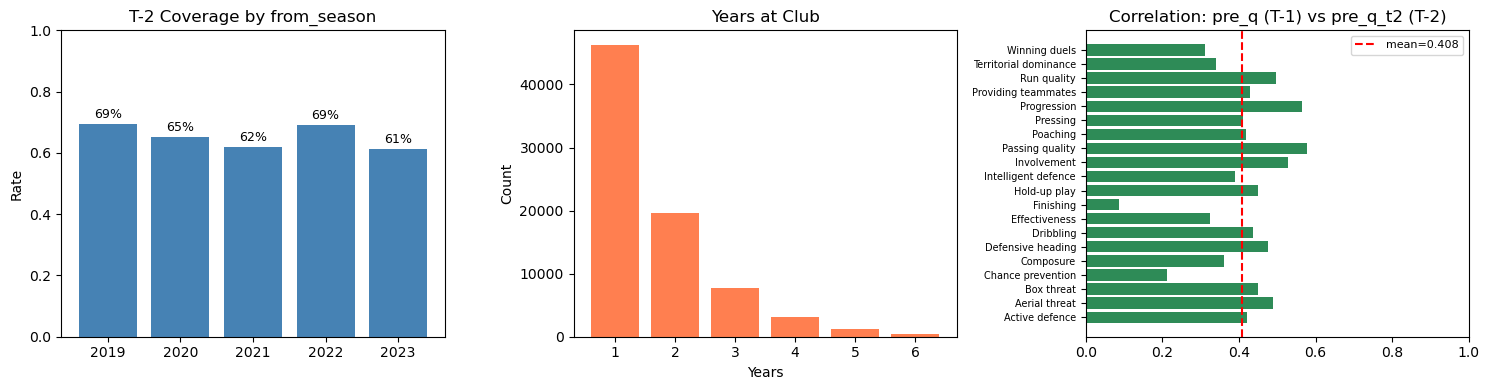


Mean T-1 vs T-2 correlation: 0.408


In [8]:
print(f'Enhanced dataset: {df.shape}')
print(f'  Original columns: {n_original_cols}')
print(f'  New columns:      {df.shape[1] - n_original_cols}')
print(f'  T-2 history rate: {df["has_t2_history"].mean():.1%}')

print(f'\n--- New feature summary ---')
for c in sorted(new_cols):
    print(f'  {c:40s}  mean={df[c].mean():8.3f}  std={df[c].std():8.3f}  nulls={df[c].isnull().sum()}')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. T-2 coverage by season
raw_coverage = df.groupby('from_season')['has_t2_history'].mean()
axes[0].bar(raw_coverage.index.astype(str), raw_coverage.values, color='steelblue')
axes[0].set_title('T-2 Coverage by from_season')
axes[0].set_ylabel('Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(raw_coverage.values):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=9)

# 2. Years at club distribution
yac = df['years_at_club'].value_counts().sort_index()
axes[1].bar(yac.index, yac.values, color='coral')
axes[1].set_title('Years at Club')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Years')

# 3. T-1 vs T-2 correlation for sample qualities (only rows with real T-2)
valid = df[df['has_t2_history'] == 1]
corrs = []
for q in QUALITIES:
    c = valid[f'pre_{q}'].corr(valid[f'pre_{q}_t2'])
    corrs.append(c)
axes[2].barh(range(len(QUALITIES)), corrs, color='seagreen')
axes[2].set_yticks(range(len(QUALITIES)))
axes[2].set_yticklabels(QUALITIES, fontsize=7)
axes[2].set_title('Correlation: pre_q (T-1) vs pre_q_t2 (T-2)')
axes[2].set_xlim(0, 1)
axes[2].axvline(x=np.mean(corrs), color='red', linestyle='--', label=f'mean={np.mean(corrs):.3f}')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nMean T-1 vs T-2 correlation: {np.mean(corrs):.3f}')

## 7. Save Enhanced Datasets

In [9]:
# All rows (same-team + transfers)
df.to_parquet(f'{OUT_DIR}/enhanced_model_df.parquet', index=False)
print(f'Saved: enhanced_model_df.parquet — {df.shape}')

# Transfers only
transfers = df[df['from_team_id'] != df['to_team_id']].reset_index(drop=True)
transfers.to_parquet(f'{OUT_DIR}/enhanced_model_df_transfers_only.parquet', index=False)
print(f'Saved: enhanced_model_df_transfers_only.parquet — {transfers.shape}')

print(f'\nOutput: {OUT_DIR}')
print(f'New features ({len(new_cols)}): {sorted(new_cols)}')

Saved: enhanced_model_df.parquet — (78231, 124)
Saved: enhanced_model_df_transfers_only.parquet — (20467, 124)

Output: /Users/jorgepadilla/Documents/Documents - Jorge’s MacBook Air/thesis_data/processed_data/model_dataset/v_3
New features (31): ['age_squared', 'from_q_proj_ATTACKING_TRANSITION_t2', 'from_q_proj_ATTACK_t2', 'from_q_proj_CHANCE_CREATION_t2', 'from_q_proj_DEFENCE_t2', 'from_q_proj_DEFENSIVE_TRANSITION_t2', 'from_q_proj_OUTCOME_t2', 'from_q_proj_PENETRATION_t2', 'has_t2_history', 'pre_Active defence_t2', 'pre_Aerial threat_t2', 'pre_Box threat_t2', 'pre_Chance prevention_t2', 'pre_Composure_t2', 'pre_Defensive heading_t2', 'pre_Dribbling_t2', 'pre_Effectiveness_t2', 'pre_Finishing_t2', 'pre_Hold-up play_t2', 'pre_Intelligent defence_t2', 'pre_Involvement_t2', 'pre_Passing quality_t2', 'pre_Poaching_t2', 'pre_Pressing_t2', 'pre_Progression_t2', 'pre_Providing teammates_t2', 'pre_Run quality_t2', 'pre_Territorial dominance_t2', 'pre_Winning duels_t2', 'pre_minutes_t2', 'yea